In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.optimize import newton

## Tabela de informações usadas

In [28]:
A_espelho = 18 * 18            # m2 - area do espelho q vai pro espaco
const_solar = 1361             # w/m2 - forca bruta do sol la no espaco
refletividade = 0.90           # espelho reflete 90% da luz
theta_sol =  9.3e-3            # angulo do sol la em radianos
altitude =  640_000            # m - altura do satelite
efic_painel =  0.20            # eficiencia do painel q vai receber a luz
area_fazenda =  5e6            # m2 - tamanho da fazenda solar la embaixo
transmissao_atm = 0.818        # 81.8% da luz cruza a atmosfera (Lei de Beer-Lambert

In [29]:
# calculando como a luz vai se espalhar ate chegar na terra
raio_feixe_espelho = altitude * theta_sol / 2          # ~2.976 m
area_feixe_espelho = math.pi * raio_feixe_espelho**2   # ~27,8 km²

# a luz sai do espaco, bate no espelho (perde 10%) e espalha
irrad_feixe = (A_espelho * const_solar * refletividade) / area_feixe_espelho

# a luz cruza a atmosfera (perde uns 18%) e chega nos paineis
potencia_eletrica_W = irrad_feixe * transmissao_atm * area_fazenda * efic_painel
E_espelho = potencia_eletrica_W / 1_000_000  # converte para megawatts-hora

# Printando os resultados das contas

In [30]:
print("=" * 60)
print("DERIVAÇÃO FÍSICA DE Em")
print(f" Raio do feixe no solo: {raio_feixe_espelho/1000:.2f} km")
print(f" Área do feixe no solo: {area_feixe_espelho/1e6:.1f} km²")
print(f" Irradiância do feixe (antes da atm): {irrad_feixe:.5f} W/m²")
print(f" Potência elétrica por espelho (na terra): {potencia_eletrica_W/1000:.2f} kW")
print(f" Em (energia/hora/espelho): {E_espelho*1000:.4f} kWh/h = {E_espelho:.6f} MWh/h")
print("=" * 60)

DERIVAÇÃO FÍSICA DE Em
 Raio do feixe no solo: 2.98 km
 Área do feixe no solo: 27.8 km²
 Irradiância do feixe (antes da atm): 0.01426 W/m²
 Potência elétrica por espelho (na terra): 11.67 kW
 Em (energia/hora/espelho): 11.6676 kWh/h = 0.011668 MWh/h


## Parte do dinheiro (custos e lucros)

In [31]:
h_ano = 1_000                      # quantidade de horas q vao vender luz no ano
V_h =   5_000                      # preco de cada hora de luz
C_m =   1_500_000                  # gasto pra manter 1 espelho por ano
DIVIDA_INICIAL = -15_000_000_000   # divida do comeco do projeto

## Metodos numericos 

In [32]:
anos_dados = np.array([2028, 2030, 2035])
espelhos_dados = np.array([1_000, 5_000, 50_000])

## interpolacao quadratica (Code Session 6)
polinomio_N = interp1d(anos_dados, espelhos_dados, kind='quadratic', fill_value='extrapolate')

def N(t):
    return float(polinomio_N(t))

## Modelagem

In [33]:
def energia_anual(t):
    return N(t) * h_ano * E_espelho

def energia_acumulada(t_alvo):
    # integracao numerica via scipy (Code Session 8)
    integral, erro = quad(energia_anual, 2028, t_alvo)
    return integral / 1_000_000 

def lucro_anual(t):
    return N(t) * (h_ano * V_h - C_m)

def lucro_acumulado(t_alvo):
    integral, erro = quad(lucro_anual, 2028, t_alvo)
    return integral

In [34]:
def f_objetivo(t):
    return lucro_acumulado(t) + DIVIDA_INICIAL

def f_derivada(t):
    return lucro_anual(t)

## 5 newton raphson via scipy (Code Session 3)
ano_break_even = newton(func=f_objetivo, x0=2032, fprime=f_derivada)

print(f"\nPonto de Equilíbrio(Break-even) -> ano: {ano_break_even:.2f}")
print(f" ( {int((ano_break_even % 1) * 12 + 0.5)}° mês de {int(ano_break_even)})")


Ponto de Equilíbrio(Break-even) -> ano: 2029.92
 ( 11° mês de 2029)


## Desenhando o grafico de eixos gemeos

In [35]:
t_grafico = np.linspace(2028, 2035, 300)
e_acumulada_plot = [energia_acumulada(t) for t in t_grafico]
l_acumulado_plot = [f_objetivo(t) / 1e9 for t in t_grafico] 

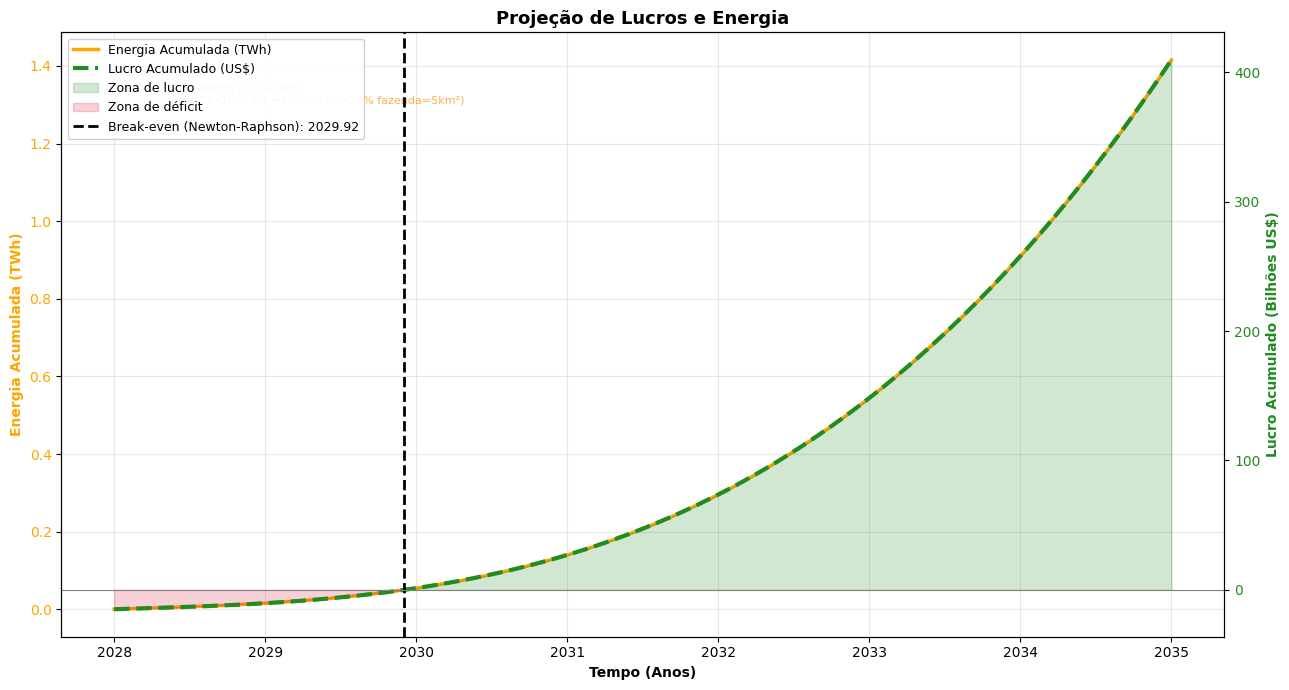

In [36]:
fig, ax1 = plt.subplots(figsize=(13, 7))

# grafico da esquerda -> energia (linha laranja)
cor_energia = 'orange'
ax1.set_xlabel('Tempo (Anos)', fontweight='bold')
ax1.set_ylabel('Energia Acumulada (TWh)', color=cor_energia, fontweight='bold')
linha1 = ax1.plot(t_grafico, e_acumulada_plot, color=cor_energia, linewidth=2.5, label='Energia Acumulada (TWh)')
ax1.tick_params(axis='y', labelcolor=cor_energia)
ax1.grid(True, alpha=0.3)

# grafico da direita -> dinheiro (linha verde/vermelho tracejada)
ax2 = ax1.twinx()
cor_lucro = 'forestgreen'
ax2.set_ylabel('Lucro Acumulado (Bilhões US$)', color=cor_lucro, fontweight='bold')
linha2 = ax2.plot(t_grafico, l_acumulado_plot, color=cor_lucro, linewidth=3, linestyle='--', label='Lucro Acumulado (US$)')
ax2.tick_params(axis='y', labelcolor=cor_lucro)

# pintando as areas no grafico
ax2.fill_between(t_grafico, l_acumulado_plot, 0, where=(np.array(l_acumulado_plot) >= 0), color='forestgreen', alpha=0.2, label='Zona de lucro')
ax2.fill_between(t_grafico, l_acumulado_plot, 0, where=(np.array(l_acumulado_plot) < 0), color='crimson', alpha=0.2, label='Zona de déficit')

ax2.axvline(x=ano_break_even, color='black', linestyle='--', linewidth=2, label=f'Break-even (Newton-Raphson): {ano_break_even:.2f}')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', framealpha=0.92, fontsize=9)

nota = (f"Em = {E_espelho*1000:.3f} kWh/h por espelho\n"
        f"(derivado de: 18x18m, alt.=640km, ef.=20% fazenda=5km²)")
ax1.annotate(nota, xy=(2028.05, max(e_acumulada_plot)*0.92), fontsize=8, color='darkorange', alpha=0.7)

plt.title('Projeção de Lucros e Energia', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()